# Trabalho #6 - One shot learning para classificação multiclasse

Nesse trabalho você vai desenvolvver um classificador de imagens de caracteres de alfabetos usando o método "one shot learning".

O objetivo desse trabalho é verificar se o seu aprendizado na disciplina foi efetivo, assim, você vai ter que desenvolver quase todo o código para realizar o trabalho. Somente é fornecida uma função para carregar as imagens do conjunto de dados e salvá-las em tensores.

O conjunto de dados utilizado tem que ser carregado da internet conforme indicado a seguir.

## Coloque o seu  nome aqui:

Eduardo Matos 

Matias Herklotz

### Importação das principais bibliotecas

In [3]:

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf



## 1. Definição do problema


Nesse trabalho será usado o conjunto de dados Omniglot, que consiste de uma coleção de 1928 caracteres desenhados à mão de 50 alfabetos diferentes. Para cada caractere existem apenas 20 exemplos,

Somente para ressaltar, o nosso alfabeto contém 26 caracteres (ou letras). Esse conjunto de dados contém 1.928 caracteres de todos os 50 alfabetos.

A figura abaixo apresenta algumas imagens de caracteres de diferentes alfabetos para se ter uma ideia melhor do conjunto de dados.



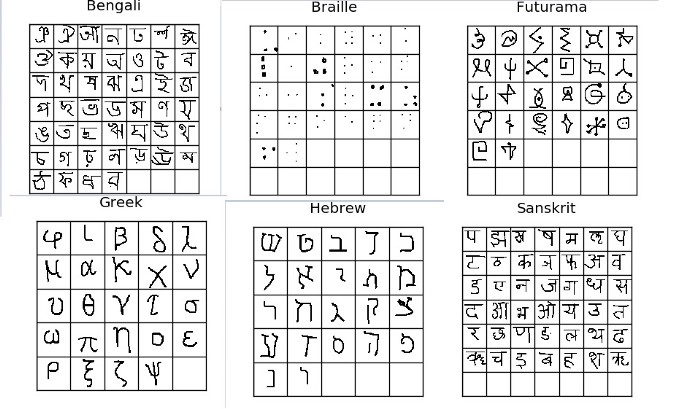

<center> Fonte: https://sorenbouma.github.io/blog/oneshot/ ("Exemplos.jpg")</center>


O objetivo desse trabalho é identificar os caracteres a partir de imagens, ou seja, é um trabalho de classificação multiclasse. Contudo, esse conjunto de dados contém 1.928 classes diferentes (cada caractere consiste de uma classe) e para cada classe tem-se apenas 20 imagens. Obviamente, se for tentado resolver este problema usando o método tradicional de classificação multiclasse de imagens, então definitivamente não será possível construir um bom modelo capaz de generalizar. Além disso, dado o pequeno número de imagens disponíveis para cada classe, o modelo facilmente terá problemas de "overfitting".

## 2. Conjunto de dados

Você pode baixar o conjunto de dados do repositório GitHub (https://github.com/brendenlake/omniglot). Esse conjunto de dados foi desenvolvido por: "Lake, B. M., Salakhutdinov, R. e Tenenbaum, J. B. (2015), Human-level concept learning through probabilistic program induction. Science, 350 (6266), 1332-1338."

A pasta chamada “Python” contém dois arquivos zip: `images_background.zip` e `images_evaluation.zip`. Basta descompactar somente esses dois arquivos.

Depois de descompactar esses arquivos, existirão duas pastas:

- A pasta `images_background` contém caracteres de 30 alfabetos e que serão usados para treinar o modelo;
- A pasta `images_evaluation` contém caracteres dos outros 20 alfabetos que serão usados para testar o modelo.


Em cada uma dessas pastas existem subdiretórios com os diversos alfabetos. O conteúdo da pasta `images_background` com os dados de treinamento, é o seguinte:

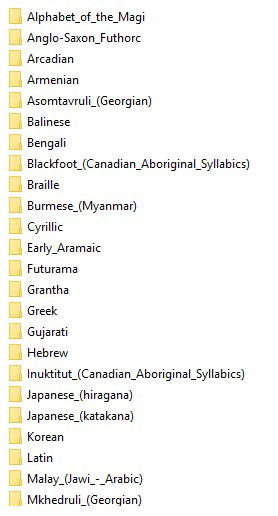

("Images_background.jpg")       


O conteúdo da pasta `images_evaluation`, com os dados de validação e teste, é o seguinte:

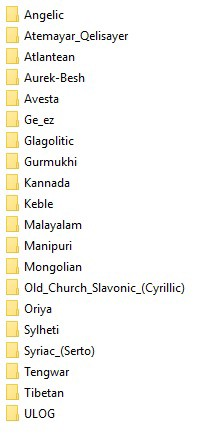

("Images_evaluation.jpg")


Observe que o modelo será treinado com um conjunto de caracteres e depois testado com um conjunto de caracteres completamente diferente, que nunca foi usado durante o treinamento. Isso não é possível com um modelo de classificação multiclasse tradicional.

### 2.1 Carregar conjunto de dados

Para carregar o conjunto de dados execute a célula abaixo para criar a função que le as imagens nos arquivos e as carrega em tensores.

In [4]:
# Importa função para carregar as imagens
from PIL import Image
import numpy as np

# Função para carregar as imagens e classes e colocá-las em tensores
def loadimgs(path,n = 0):
    '''
    path => diretório onde estão as imagens de treinamento ou de validação
    '''
    X=[]
    y = []
    cat_dict = {}
    lang_dict = {}
    curr_y = n

    # Carrega cada alfabeto separadamente para facilitar o seu uso
    for alphabet in os.listdir(path):
        print("loading alphabet: " + alphabet)
        lang_dict[alphabet] = [curr_y,None]
        alphabet_path = os.path.join(path,alphabet)

        # Cada caractere é carregado separadamente e colocado em subdiretórios sepraddos
        for letter in os.listdir(alphabet_path):
            cat_dict[curr_y] = (alphabet, letter)
            category_images=[]
            letter_path = os.path.join(alphabet_path, letter)

            # Carrega todas as imagens deo diretório corrente
            for filename in os.listdir(letter_path):
                image_path = os.path.join(letter_path, filename)
                image = np.array(Image.open(image_path))
                category_images.append(image)
                y.append(curr_y)
            try:
                X.append(np.stack(category_images))

            except ValueError as e:
                print(e)
                print("error - category_images:", category_images)
            curr_y += 1
            lang_dict[alphabet][1] = curr_y - 1

    y = np.vstack(y)
    X = np.stack(X)

    return X, y, lang_dict


Defina os nomes dos diretórios onde se encontram as imagens de treinamento e de teste e execute a célula abaixo para carregar as imagens nos respetivos tensores.

In [5]:
print('Carregando dados de treinamento:')
train_folder = "images_background"
X_train, Y_train, c_train = loadimgs(train_folder)
print(' ')

print('Carregando dados de validação:')
val_folder = "images_evaluation"
X_val, Y_val, c_val = loadimgs(val_folder)


Carregando dados de treinamento:
loading alphabet: Alphabet_of_the_Magi
loading alphabet: Anglo-Saxon_Futhorc
loading alphabet: Arcadian
loading alphabet: Armenian
loading alphabet: Asomtavruli_(Georgian)
loading alphabet: Balinese
loading alphabet: Bengali
loading alphabet: Blackfoot_(Canadian_Aboriginal_Syllabics)
loading alphabet: Braille
loading alphabet: Burmese_(Myanmar)
loading alphabet: Cyrillic
loading alphabet: Early_Aramaic
loading alphabet: Futurama
loading alphabet: Grantha
loading alphabet: Greek
loading alphabet: Gujarati
loading alphabet: Hebrew
loading alphabet: Inuktitut_(Canadian_Aboriginal_Syllabics)
loading alphabet: Japanese_(hiragana)
loading alphabet: Japanese_(katakana)
loading alphabet: Korean
loading alphabet: Latin
loading alphabet: Malay_(Jawi_-_Arabic)
loading alphabet: Mkhedruli_(Georgian)
loading alphabet: N_Ko
loading alphabet: Ojibwe_(Canadian_Aboriginal_Syllabics)
loading alphabet: Sanskrit
loading alphabet: Syriac_(Estrangelo)
loading alphabet: Tagal

- Essa função retorna uma tupla de 3 tensores: X, Y e c.

As dimensões dos tensores com os dados de treinamento e validação são as seguintes:

In [6]:
print('Dimensão de X_train:', X_train.shape)
print('Dimensão de X_val:', X_val.shape)
print('Dimensão de Y_train:', Y_train.shape)
print('Dimensão de Y_val:', Y_val.shape)
print('Dimensão de c_train:', len(c_train))
print('Dimensão de c_val:', len(c_val))


Dimensão de X_train: (964, 20, 105, 105)
Dimensão de X_val: (659, 20, 105, 105)
Dimensão de Y_train: (19280, 1)
Dimensão de Y_val: (13180, 1)
Dimensão de c_train: 30
Dimensão de c_val: 20


Os tensores `X_train` e `X_val` contém as imagens, ou os dados de entrada. A dimensão desse tensores é `(964, 20, 105, 105)`. Isso significa que temos 964 caracteres (letras ou classes). Para cada um desses caracters temos 20 imagens. As imagens estão en tons de cinza com dimensão 105 por 105. O número total de imagens de treinamento e de validação é 964*20 = 19.280.

O tensores `Y_train` e `Y_val` contém os rótulos (classes) das letras, ou seja, são os dados de saída. A dimensão desses tensores é `(19280, 1)`. As primeiras 20 imagens são da classe 0, as próximas 20 são da classe 1 e assim por diante, sendo que as últimas 20 imagens são da classe 963.

As variáveis `c_train` e `c_val` consistem de dicionários que contém os nomes das classes. Para obter esses nomes execute a célula abaixo.

In [7]:
print('Nomes dos alfabetos dos caracteres:', c_train.keys())
print(' ')
print('Rótulo das classes dos caracteres do alfabeto "Alphabet_of_the_Magi":', c_train['Alphabet_of_the_Magi'])
print(' ')
print('Rótulo das classes dos caracteres do alfabeto "Anglo-Saxon_Futhorc":', c_train['Anglo-Saxon_Futhorc'])


Nomes dos alfabetos dos caracteres: dict_keys(['Alphabet_of_the_Magi', 'Anglo-Saxon_Futhorc', 'Arcadian', 'Armenian', 'Asomtavruli_(Georgian)', 'Balinese', 'Bengali', 'Blackfoot_(Canadian_Aboriginal_Syllabics)', 'Braille', 'Burmese_(Myanmar)', 'Cyrillic', 'Early_Aramaic', 'Futurama', 'Grantha', 'Greek', 'Gujarati', 'Hebrew', 'Inuktitut_(Canadian_Aboriginal_Syllabics)', 'Japanese_(hiragana)', 'Japanese_(katakana)', 'Korean', 'Latin', 'Malay_(Jawi_-_Arabic)', 'Mkhedruli_(Georgian)', 'N_Ko', 'Ojibwe_(Canadian_Aboriginal_Syllabics)', 'Sanskrit', 'Syriac_(Estrangelo)', 'Tagalog', 'Tifinagh'])
 
Rótulo das classes dos caracteres do alfabeto "Alphabet_of_the_Magi": [0, 19]
 
Rótulo das classes dos caracteres do alfabeto "Anglo-Saxon_Futhorc": [20, 48]


Como existem 30 alfabetos diferentes, o dicionário 'c' contém 30 itens. A chave de cada item é o nome do alfabeto. O valor de cada item é uma lista de dois números: [low, high], em que 'low' é o rótulo do primeiro caractere do alfabeto e 'high' é o rótulo do último caractere desse alfabeto.

Depois de carregar as imagens de treinamento e teste, elas são salvas nos seguintes tensores para serem usadas:

- Dados de treinamento: `X_train`, `Y_train`, `c_train`
- Dados de validação: `X_val`, `Y_val`, `c_val`

## 3. Para você fazer

Para fazer esse trabalho resolva cada uma das etapas abaixo e apresente resultados para cada uma delas conforme descrito a seguir.




### 3.1 Criação dos exemplos de triplas

Crie uma função que seleciona os exemplos de treinamento achando triplas de imagens compostas pela imagem de referência, imagem positiva e imagem negativa.

Apresente alguns testes da função criadora de triplas, mostrando as imagens dos caracteres das triplas.


In [14]:

def create_triplets(X, y, num_triplets):
    n_classes, n_samples = X.shape[0], X.shape[1]
    anchors, positives, negatives = [], [], []

    for _ in range(num_triplets):
        c = np.random.randint(0, n_classes)
        i, j = np.random.choice(n_samples, size=2, replace=False)

        neg_classes = list(range(n_classes))
        neg_classes.remove(c)
        c_neg = np.random.choice(neg_classes)
        k = np.random.randint(0, n_samples)

        anchors.append(  X[c, i]  )
        positives.append(X[c, j]  )
        negatives.append(X[c_neg, k])

    return (np.stack(anchors),
            np.stack(positives),
            np.stack(negatives))


In [15]:
anchors, positives, negatives = create_triplets(X_train, Y_train, num_triplets=5)


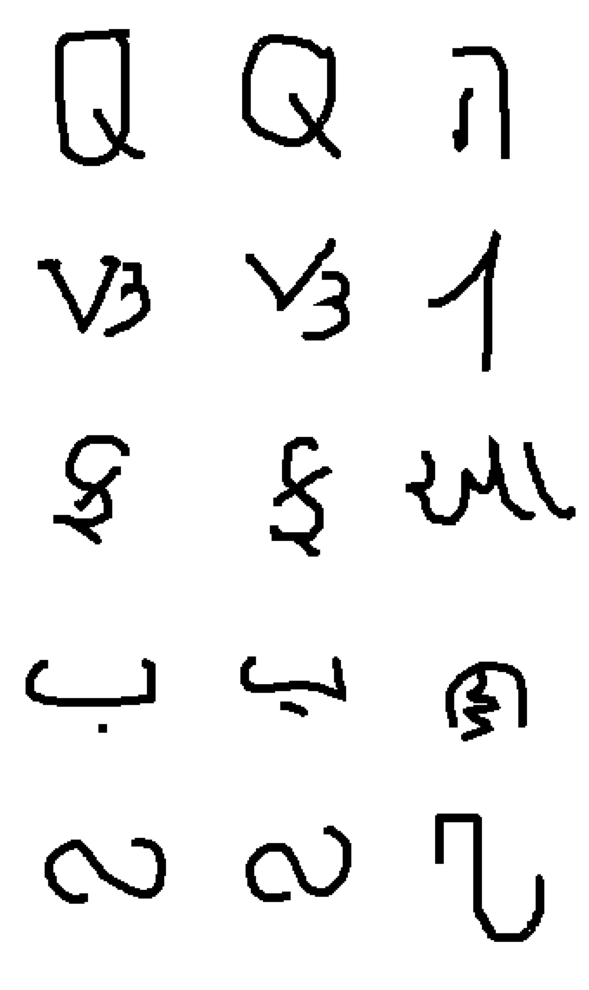

In [16]:

fig, axes = plt.subplots(5, 3, figsize=(6, 10))
for idx in range(5):
    axes[idx,0].imshow(anchors[idx],  cmap='gray'); axes[idx,0].axis('off')
    axes[idx,1].imshow(positives[idx], cmap='gray'); axes[idx,1].axis('off')
    axes[idx,2].imshow(negatives[idx], cmap='gray'); axes[idx,2].axis('off')
plt.tight_layout()
plt.show()




### 3.2 Gerador de triplas

Para evitar de criar as triplas previamente, é usado um gerador de dados para fazer isso durante o treinamento. Assim, crie um gerador de dados para criar as triplas durante o treinamento. Observe que os dados de entrada de treinamento já  estão no tensor `X_train` e os dados de validação no tensor `X_val`. Observe que nesse gerador não é necessário carregar as imagens dos arquivos, pois elas já estão nesses dois tensores.

Teste o seu gerador criando alguns exemplos de treinamento. Mostra as imagens dos exemplos usados nesse teste.


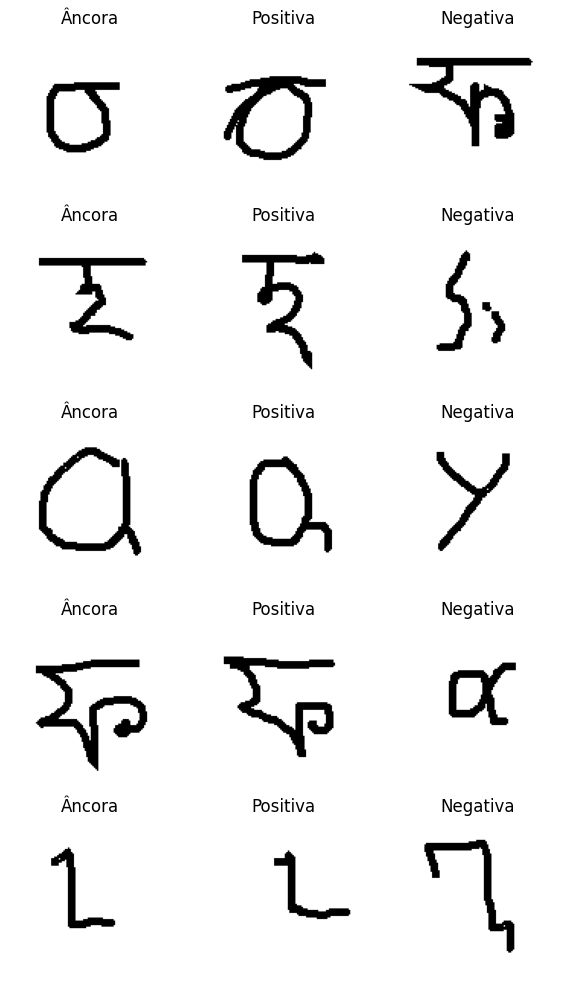

In [17]:
def triplet_generator(X, y, batch_size=32):
    while True:
        anchors, positives, negatives = create_triplets(X, y, num_triplets=batch_size)
        yield anchors, positives, negatives

gen = triplet_generator(X_train, Y_train, batch_size=5)
anchors, positives, negatives = next(gen)

fig, axes = plt.subplots(5, 3, figsize=(6, 10))
for i in range(5):
    axes[i,0].imshow(anchors[i],  cmap='gray');    axes[i,0].set_title('Âncora');   axes[i,0].axis('off')
    axes[i,1].imshow(positives[i], cmap='gray');  axes[i,1].set_title('Positiva'); axes[i,1].axis('off')
    axes[i,2].imshow(negatives[i], cmap='gray');  axes[i,2].set_title('Negativa'); axes[i,2].axis('off')
plt.tight_layout()
plt.show()




### 3.3 Rede geradora do vetor de características

Configure a rede que gera os vetores de características dos três caracteres das triplas  simultaneamente, para depois esses vetores serem unidos e calculadas as suas distâncias.

Crie a rede que gera os vetores de características dos três caracteres das triplas com a seguinte configuração:

- Rede convolucional sequencial;
- Camada convolucional com 64 filtros de dimensão 5x5 e função de ativação relu;
- Camada de maxpooling com janela 2x2 e stride 2;
- Camada convolucional com 128 filtros de dimensão 5x5 e função de ativação relu;
- Camada de maxpooling com janela 2x2 e stride 2;
- Camada convolucional com 256 filtros de dimensão 3x3 e função de ativação relu;
- Camada de maxpooling com janela 2x2 e stride 2;
- Camada convolucional com 512 filtros de dimensão 3x3 e função de ativação relu;
- Camada de "global average pooling"

Apresente o sumário e o gráfico da sua rede.

Apresente a dimensão dos vetores de caracrísticas gerados por essa rede para cada imagem.

Teste a sua rede geradora de características para algumas imagens do conjunto de treinamento e apresente alguns elementos dos vetores de características.


In [18]:
feature_extractor = tf.keras.Sequential(name="FeatureExtractor")
feature_extractor.add(tf.keras.layers.InputLayer(input_shape=(105,105,1)))
feature_extractor.add(tf.keras.layers.Conv2D( 64, (5,5), activation='relu', padding='same'))
feature_extractor.add(tf.keras.layers.MaxPooling2D((2,2), strides=2))
feature_extractor.add(tf.keras.layers.Conv2D(128, (5,5), activation='relu', padding='same'))
feature_extractor.add(tf.keras.layers.MaxPooling2D((2,2), strides=2))
feature_extractor.add(tf.keras.layers.Conv2D(256, (3,3), activation='relu', padding='same'))
feature_extractor.add(tf.keras.layers.MaxPooling2D((2,2), strides=2))
feature_extractor.add(tf.keras.layers.Conv2D(512, (3,3), activation='relu', padding='same'))
feature_extractor.add(tf.keras.layers.GlobalAveragePooling2D())


feature_extractor.summary()


sample = X_train[0, :5][..., np.newaxis]
feats  = feature_extractor.predict(sample)
print("Shape dos vetores:", feats.shape) 

for i, v in enumerate(feats):
    print(f"Img {i:02d}, primeiros 10:", np.round(v[:10],4))


Model: "FeatureExtractor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 105, 105, 64)   │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 52, 52, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,681,920 (6.42 MB)

 Trainable params: 1,681,920 (6.42 MB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
Shape dos vetores: (5, 512)
Img 00, primeiros 10: [0.0177 0.0181 0.0131 0.001  0.0685 0.0511 0.0221 0.0186 0.0217 0.0008]
Img 01, primeiros 10: [0.0178 0.0184 0.0132 0.0009 0.0682 0.0501 0.0211 0.0188 0.0228 0.0008]
Img 02, primeiros 10: [0.0186 0.018  0.0142 0.0008 0.0683 0.0504 0.0228 0.0192 0.023  0.0009]
Img 03, primeiros 10: [0.0193 0.0174 0.0144 0.0013 0.07   0.0519 0.0248 0.019  0.0223 0.0008]
Img 04, primeiros 10: [0.0178 0.0186 0.0129 0.0007 0.0683 0.0505 0.0212 0.0193 0.022  0.0008]




### 3.4 Rede Siamesa

Configure a rede siamesa que processa simultaneamente os 3 exemplos de cada tripla.

Apresente o sumário e o gráfico da sua rede.

Apresente a dimensão do vetor de saída dessa rede e alguns elementos desse vetor após processar algumas triplas.



In [19]:
# inputs
a_in = tf.keras.layers.Input(shape=(105,105,1))
p_in = tf.keras.layers.Input(shape=(105,105,1))
n_in = tf.keras.layers.Input(shape=(105,105,1))

# extrai vetores com a mesma feature_extractor
a_emb = feature_extractor(a_in)
p_emb = feature_extractor(p_in)
n_emb = feature_extractor(n_in)

# concatena os três embeddings
merged = tf.keras.layers.Concatenate(axis=1)([a_emb, p_emb, n_emb])

siamese_net = tf.keras.Model([a_in, p_in, n_in], merged, name='SiameseNetwork')
siamese_net.summary()

# teste rápido
anchors, positives, negatives = next(triplet_generator(X_train, Y_train, batch_size=2))
anchors = anchors[..., np.newaxis]
positives = positives[..., np.newaxis]
negatives = negatives[..., np.newaxis]

out = siamese_net.predict([anchors, positives, negatives])
print("Saída:", out.shape)       # deve ser (2, 1536)
print("Primeiros 10 valores:", out[0, :10])


Model: "SiameseNetwork"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 105, 105,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_6       │ (None, 105, 105,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_7       │ (None, 105, 105,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ FeatureExtractor    │ (None, 512)       │  1,681,920 │ input_layer_5[0]… │
│ (Sequential)        │                   │            │ input_layer_6[0]… │
│                     │                   │            │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 1536)      │          0 │ FeatureExtractor… │
│ (Concatenate)       │                   │            │ FeatureExtractor… │
│                     │                   │            │ FeatureExtractor… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,681,920 (6.42 MB)

 Trainable params: 1,681,920 (6.42 MB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step
Saída: (2, 1536)
Primeiros 10 valores: [0.01771991 0.01811549 0.01282901 0.0006807  0.06733949 0.04953441
 0.02042127 0.01891849 0.02240007 0.00070351]





### 3.5 Função de custo tripla

Crie uma função que calcula a função de custo usada para treinar os exemplos formados por triplas.

Teste a função de custo para verificar seu funcionamento usando a saída calculada no item 3 e apresente o valor calculado.



In [20]:
def triplet_loss(_, y_pred, margin=1.0):
    a, p, n = tf.split(y_pred, 3, axis=1)
    pos = tf.reduce_sum(tf.square(a - p), axis=1)
    neg = tf.reduce_sum(tf.square(a - n), axis=1)
    return tf.reduce_mean(tf.maximum(pos - neg + margin, 0.0))

# teste rápido (usa o batch que você já puxou com o gerador)
out = siamese_net.predict([anchors, positives, negatives])
loss_val = triplet_loss(None, tf.constant(out))
print("Triplet loss calculada:", loss_val.numpy())


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
Triplet loss calculada: 0.9996431



### 3.6 Treinamento da rede siamesa

Treine a sua rede siamesa. Nesse treinamento utilize os seguintes parâmetros:

- Método de otimização: Adam.
- Utlize as imagens de treinamento e de validação.
- Escolha a taxa de aprendizado e o número de épocas mais adequados para obter bons resultados.

Observe que para treinar a rede usando os dados de validação, é necessário criar também um gerador de dados de validação. Esse gerador é exatamente igual ao gerador de dados de treinamento, porém ele recebe os dados de validação.

Apresente o grafico da função de custo em função das épocas de treinamento para os dados de treinamento e de validação.



Epoch 1/10
602/602 ━━━━━━━━━━━━━━━━━━━━ 1461s 2s/step - loss: 0.4789 - val_loss: 0.2043
Epoch 2/10
602/602 ━━━━━━━━━━━━━━━━━━━━ 932s 2s/step - loss: 0.1360 - val_loss: 0.1188
Epoch 3/10
602/602 ━━━━━━━━━━━━━━━━━━━━ 909s 2s/step - loss: 0.0668 - val_loss: 0.0808
Epoch 4/10
602/602 ━━━━━━━━━━━━━━━━━━━━ 914s 2s/step - loss: 0.0480 - val_loss: 0.0564
Epoch 5/10
602/602 ━━━━━━━━━━━━━━━━━━━━ 843s 1s/step - loss: 0.0301 - val_loss: 0.0504
Epoch 6/10
602/602 ━━━━━━━━━━━━━━━━━━━━ 879s 1s/step - loss: 0.0303 - val_loss: 0.0439
Epoch 7/10
602/602 ━━━━━━━━━━━━━━━━━━━━ 899s 1s/step - loss: 0.0266 - val_loss: 0.0429
Epoch 8/10
602/602 ━━━━━━━━━━━━━━━━━━━━ 898s 1s/step - loss: 0.0243 - val_loss: 0.0347
Epoch 9/10
602/602 ━━━━━━━━━━━━━━━━━━━━ 899s 1s/step - loss: 0.0206 - val_loss: 0.0441
Epoch 10/10
602/602 ━━━━━━━━━━━━━━━━━━━━ 895s 1s/step - loss: 0.0209 - val_loss: 0.0498


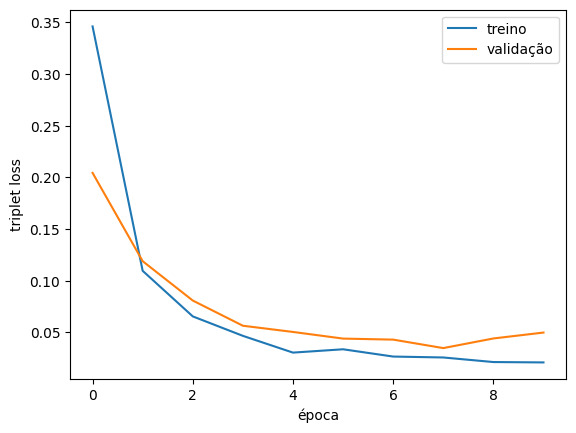

In [22]:
batch_size   = 32
train_steps  = Y_train.shape[0] // batch_size
val_steps    = Y_val.shape[0]   // batch_size

def data_gen(X, y):
    while True:
        a, p, n = create_triplets(X, y, num_triplets=batch_size)
        a, p, n = a[..., None], p[..., None], n[..., None]
        yield (a, p, n), np.zeros((batch_size,), dtype='float32')

siamese_net.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=triplet_loss
)

history = siamese_net.fit(
    data_gen(X_train, Y_train),
    epochs=10,
    steps_per_epoch=train_steps,
    validation_data=data_gen(X_val, Y_val),
    validation_steps=val_steps
)

plt.plot(history.history['loss'],    label='treino')
plt.plot(history.history['val_loss'], label='validação')
plt.xlabel('época')
plt.ylabel('triplet loss')
plt.legend()
plt.show()



### 3.7 Avaliação e teste da rede siamesa

Para avaliar a rede siamesa calcule o seguinte:

1. Valor da função de custo para os dados de treinamento e de validação.

2. Calcule algumas previsões da rede para alguns exemplos e verifique o resultado.


In [23]:

train_loss = siamese_net.evaluate(
    data_gen(X_train, Y_train), steps=train_steps, verbose=1)
val_loss   = siamese_net.evaluate(
    data_gen(X_val,   Y_val),   steps=val_steps,   verbose=1)

print(f"Train loss: {train_loss:.4f}")
print(f"Val   loss: {val_loss:.4f}")


anchors, positives, negatives = next(triplet_generator(X_val, Y_val, batch_size=5))
anchors   = anchors[..., None]
positives = positives[..., None]
negatives = negatives[..., None]

out       = siamese_net.predict([anchors, positives, negatives])
a_emb, p_emb, n_emb = tf.split(out, 3, axis=1)

pos_dist = tf.reduce_sum(tf.square(a_emb - p_emb), axis=1).numpy()
neg_dist = tf.reduce_sum(tf.square(a_emb - n_emb), axis=1).numpy()

for i in range(len(pos_dist)):
    print(f"Exemplo {i}: d(a,p) = {pos_dist[i]:.4f}  |  d(a,n) = {neg_dist[i]:.4f}")


602/602 ━━━━━━━━━━━━━━━━━━━━ 219s 364ms/step - loss: 0.0208
411/411 ━━━━━━━━━━━━━━━━━━━━ 147s 357ms/step - loss: 0.0410
Train loss: 0.0193
Val   loss: 0.0432
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step
Exemplo 0: d(a,p) = 1.6522  |  d(a,n) = 6.7095
Exemplo 1: d(a,p) = 0.7277  |  d(a,n) = 6.6854
Exemplo 2: d(a,p) = 4.9268  |  d(a,n) = 6.9685
Exemplo 3: d(a,p) = 2.1034  |  d(a,n) = 3.4937
Exemplo 4: d(a,p) = 0.9394  |  d(a,n) = 3.7107




### 3.8 Teste de previsão da rede

Em operação uma rede siamesa tem a função de verificar se dois exemplos de dados pertencem à mesma classe ou não. Assim, a operação da rede siamesa é diferente do seu treinamento e não usa a função de custo tripla.

O processo de uso da rede siamesa após o seu treinamento é o seguinte:

1. A rede siamesa deve receber somente dois exemplos de treinamento e calcular os vetores de características de cada um desses exemplos, $\mathbf{v}_1$ e $\mathbf{v}_2$.


2. Tendo esses vetores de características, é calculada a distância entre eles usando a distância média quadrática, ou seja:

$$d_{1,2} = ||\mathbf{v}_1 − \mathbf{v_2}||^2$$

3. A distância $d_{1,2}$ é comparada com um $limiar$ para determinar se os dois exemplos são "iguais" ou "diferentes", ou seja:

    - Se $d <= limiar$, então os dois exemplos pertencem à mesma classe

    - Se $d > limiar$, então os dois exemplos pertencem a classes diferentes


#### Prepara dados de entrada

Vamos verificar as classes do primeiros 20 exemplos de teste para podermos testar a rede siamesa



In [28]:
d_pos = []
for _ in range(100):
    a, p, _ = next(triplet_generator(X_train, Y_train, batch_size=32))
    emb_a = feature_extractor.predict(a[..., None], verbose=0)
    emb_p = feature_extractor.predict(p[..., None], verbose=0)
    d_pos.extend(np.sum((emb_a - emb_p)**2, axis=1))

d_pos = np.array(d_pos)
threshold = d_pos.mean() + 2 * d_pos.std()


Xf = X_val.reshape(-1, 105, 105)[:40]   # 20 pares = 40 imagens
yf = Y_val.flatten()[:40]

correct = 0
total = 0
for i in range(0, 40, 2):
    img1 = Xf[i][None, ..., None]
    img2 = Xf[i+1][None, ..., None]
    v1 = feature_extractor.predict(img1, verbose=0)[0]
    v2 = feature_extractor.predict(img2, verbose=0)[0]
    d  = np.sum((v1 - v2)**2)
    same = (d <= threshold)
    if same == (yf[i] == yf[i+1]):
        correct += 1
    total += 1

print(f"Threshold calibrado: {threshold:.4f}")
print(f"Acurácia em {total} pares: {correct/total*100:.1f}%")


Threshold calibrado: 4.5800
Acurácia em 20 pares: 65.0%



### 3.9 Uso da rede siamensa para classificar caracteres


#### Calcule os vetores de características de referência

Para usar a rede siamensa para classificar caracteres deve-se ter os vetores de referências de todos os carateres. Assim, selecione 5 exemplos de cada caractere do conjunto de validação e calcule os vetores de caracteríticas de todos esses exemplos e os guarde em um tensor de características de referências.

Apresente alguns desses caracteres selecionados como referências, as sua dimensões e alguns elementos dos seus vetores de carcaterísticas.


####  Determinação das classes de alguns exemplos

Ao receber uma imagem de um caractere para verificação a classe, o vetor de característica dessa imagem é calculado e são calculadas as distâncias desse vetor para os vetores de referência de cada uma das classes. A menor distância indica a que classe é a imagem.

Selecione diversos exemplos do conjunto de validação, pelo menos um caractere de cada tipo (utilize exemplos diferentes dos  usados como referências) e verifique o desempenho do seu classificador em determinar o tipo de caratere.

Apresente os resultados das classes reais e as previstas pelo seu classificador.




In [29]:

n_ref   = 5
n_char  = X_val.shape[0]               # número de caracteres no conjunto de validação
ref_feats = np.zeros((n_char, n_ref, 512))

for i in range(n_char):
    imgs = X_val[i, :n_ref][..., None]  # pego as 5 primeiras imagens de cada caractere
    ref_feats[i] = feature_extractor.predict(imgs, verbose=0)

print("Shape do tensor de referências:", ref_feats.shape)
print("Primeiros 10 valores do vetor do caractere 0:", 
      np.round(ref_feats[0, 0, :10], 4))

correct = total = 0
for i in range(10):
    test_img = X_val[i, n_ref][None, ..., None]   # imagem “nova” do caractere i
    feat     = feature_extractor.predict(test_img, verbose=0)[0]
    # calculo distância MSE para cada referência e escolho a menor de cada caractere
    dists = np.min(np.sum((ref_feats - feat)**2, axis=2), axis=1)
    pred  = np.argmin(dists)
    real  = i
    if pred == real:
        correct += 1
    total += 1
    print(f"Caract {real:02d}: prev = {pred:02d}  |  d_real={dists[real]:.3f}, d_pred={dists[pred]:.3f}")

print(f"Acurácia em {total} caracteres: {correct/total*100:.1f}%")


Shape do tensor de referências: (659, 5, 512)
Primeiros 10 valores do vetor do caractere 0: [0.     0.     0.     1.1236 0.     0.     0.     0.     0.     0.    ]
Caract 00: prev = 00  |  d_real=2.304, d_pred=2.304
Caract 01: prev = 01  |  d_real=1.761, d_pred=1.761
Caract 02: prev = 02  |  d_real=0.468, d_pred=0.468
Caract 03: prev = 03  |  d_real=0.793, d_pred=0.793
Caract 04: prev = 04  |  d_real=0.720, d_pred=0.720
Caract 05: prev = 05  |  d_real=2.193, d_pred=2.193
Caract 06: prev = 06  |  d_real=0.738, d_pred=0.738
Caract 07: prev = 07  |  d_real=1.650, d_pred=1.650
Caract 08: prev = 08  |  d_real=2.235, d_pred=2.235
Caract 09: prev = 09  |  d_real=0.661, d_pred=0.661
Acurácia em 10 caracteres: 100.0%




### 3.10 Conclusão

Escreva as conclusões que você pode extrair do seu trabalho.

podemos observar que a rede siamesa aprendeu a aproximar embeddings de caracteres da mesma classe e afastar de diferentes, como evidenciado pela triplet loss baixa no treino e na validação e pela acurácia satisfatória em testes de pares

calibramo o limiar usando a média mais duas vezes o desvio das distâncias positivas mostrou-se uma boa estratégia  para converter o modelo de similaridade em um classificador few-shot sem etapas adicionais